In [1]:
from pathlib import Path
import sys
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

D:\Anaconda\Lib\site-packages\pandas\core\computation\expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [2]:
PROJECT_ROOT = Path.cwd().parent

In [3]:
sys.path.append(str(PROJECT_ROOT))

In [4]:
from src import config

In [6]:
df = pd.read_csv(config.RAW_DATA_PATH)

In [8]:
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  str    
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  str    
 5   loan_grade                  32581 non-null  str    
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  str    
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), str(4)
memory usage: 3.5 MB


In [10]:
df.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


In [12]:
df[df["loan_percent_income"] == 0] # kucuk oranlar sıfıra yuvarlanmis.

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
17834,34,948000,MORTGAGE,18.0,PERSONAL,B,2000,9.99,0,0.0,N,7
18917,35,510000,RENT,1.0,PERSONAL,C,1800,13.48,0,0.0,N,6
27877,30,522000,MORTGAGE,11.0,HOMEIMPROVEMENT,A,2500,7.43,0,0.0,N,9
30049,42,2039784,RENT,0.0,VENTURE,C,8450,12.29,0,0.0,Y,15
31916,43,780000,MORTGAGE,2.0,HOMEIMPROVEMENT,A,1000,8.94,0,0.0,N,11
31922,47,1362000,MORTGAGE,9.0,VENTURE,A,6600,7.74,0,0.0,N,17
31924,44,1440000,MORTGAGE,7.0,DEBTCONSOLIDATION,A,6400,7.40,0,0.0,N,15
32297,144,6000000,MORTGAGE,12.0,PERSONAL,C,5000,12.73,0,0.0,N,25
32546,60,1900000,MORTGAGE,5.0,PERSONAL,A,1500,NaN,0,0.0,N,21


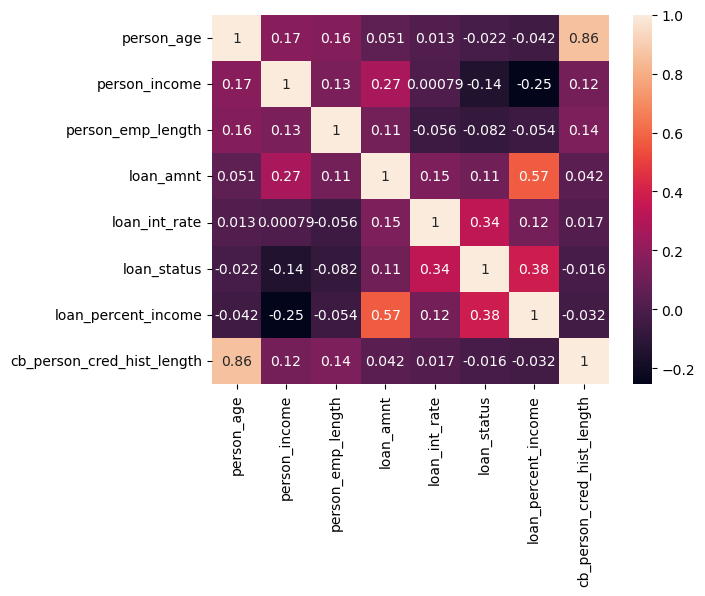

In [14]:
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.show()

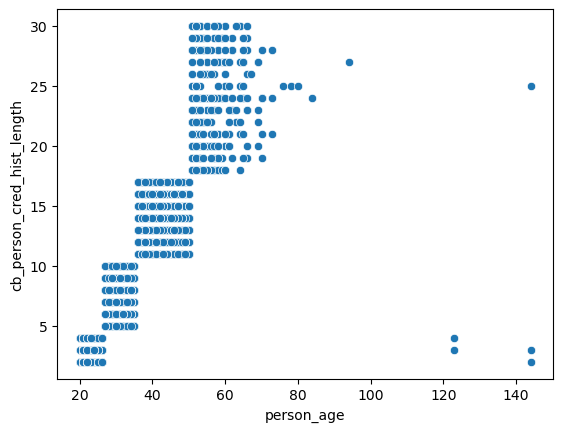

In [15]:
sns.scatterplot(data=df, x="person_age", y="cb_person_cred_hist_length")
plt.show()

In [17]:
df = df[df["person_age"] < 100].copy()

In [18]:
df

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4
...,...,...,...,...,...,...,...,...,...,...,...,...
32576,57,53000,MORTGAGE,1.0,PERSONAL,C,5800,13.16,0,0.11,N,30
32577,54,120000,MORTGAGE,4.0,PERSONAL,A,17625,7.49,0,0.15,N,19
32578,65,76000,RENT,3.0,HOMEIMPROVEMENT,B,35000,10.99,1,0.46,N,28
32579,56,150000,MORTGAGE,5.0,PERSONAL,B,15000,11.48,0,0.10,N,26


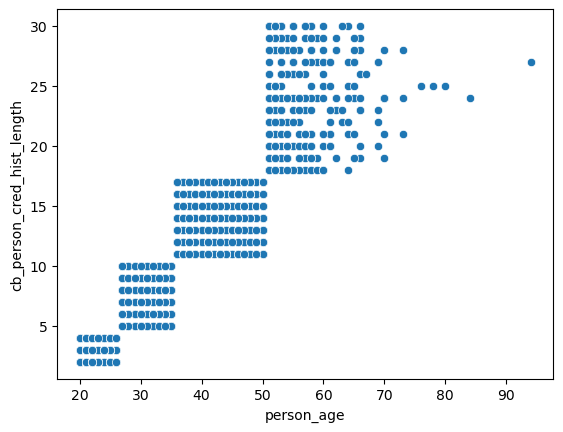

In [19]:
sns.scatterplot(data=df, x="person_age", y="cb_person_cred_hist_length")
plt.show()

In [21]:
df.corr(numeric_only=True)

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
person_age,1.000000,0.140404,0.166249,0.051566,0.011967,-0.020721,-0.041665,0.878092
person_income,0.140404,1.000000,0.152717,0.317482,-0.001243,-0.168507,-0.294525,0.123006
person_emp_length,0.166249,0.152717,1.000000,0.113142,-0.056440,-0.082475,-0.054047,0.144487
loan_amnt,0.051566,0.317482,0.113142,1.000000,0.146879,0.105411,0.572567,0.042119
loan_int_rate,0.011967,-0.001243,-0.056440,0.146879,1.000000,0.335169,0.120414,0.016639
loan_status,-0.020721,-0.168507,-0.082475,0.105411,0.335169,1.000000,0.379374,-0.015504
loan_percent_income,-0.041665,-0.294525,-0.054047,0.572567,0.120414,0.379374,1.000000,-0.031514
cb_person_cred_hist_length,0.878092,0.123006,0.144487,0.042119,0.016639,-0.015504,-0.031514,1.000000


In [22]:
def find_outliers_iqr(df, threshold=1.5):
    outlier_summary = {}

    numeric_cols = df.select_dtypes(include=["float", "int"]).columns

    for col in numeric_cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3-Q1
        

        low_whisker = Q1 - IQR*threshold
        up_whisker = Q3 + IQR*threshold

        outliers = df[(df[col] < low_whisker) | (df[col] > up_whisker)]
        outlier_summary[col] = {
            "outlier_count": outliers.shape[0],
            "outlier_percentage": outliers.shape[0]/df.shape[0] *100,
            "low_whisker": low_whisker,
            "up_whisker": up_whisker
        }
    return pd.DataFrame(outlier_summary)



import math

def plot_all_histograms(df, title_prefix=""):
    num_cols = df.select_dtypes(exclude="O").columns
    n_cols = 3
    n_rows = math.ceil(len(num_cols) / n_cols)
    plt.figure(figsize=(3*n_cols, 2*n_rows))

    for i, col in enumerate(num_cols,1):
        plt.subplot(n_rows, n_cols, i)
        sns.histplot(df[col], bins=30, kde=True)
        plt.title(f"{title_prefix} {col}")
        plt.xlabel("")
        plt.ylabel("")

    plt.tight_layout()
    plt.show()

In [23]:
find_outliers_iqr(df, threshold=1.5)

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
outlier_count,1489.00000,1481.000000,853.000000,1689.000000,6.000000,7108.000000,651.000000,1141.000000
outlier_percentage,4.57085,4.546292,2.618492,5.184799,0.018418,21.819745,1.998404,3.502579
low_whisker,12.50000,-22550.000000,-5.500000,-5800.000000,-0.455000,0.000000,-0.120000,-4.500000
up_whisker,40.50000,140250.000000,14.500000,23000.000000,21.825000,0.000000,0.440000,15.500000


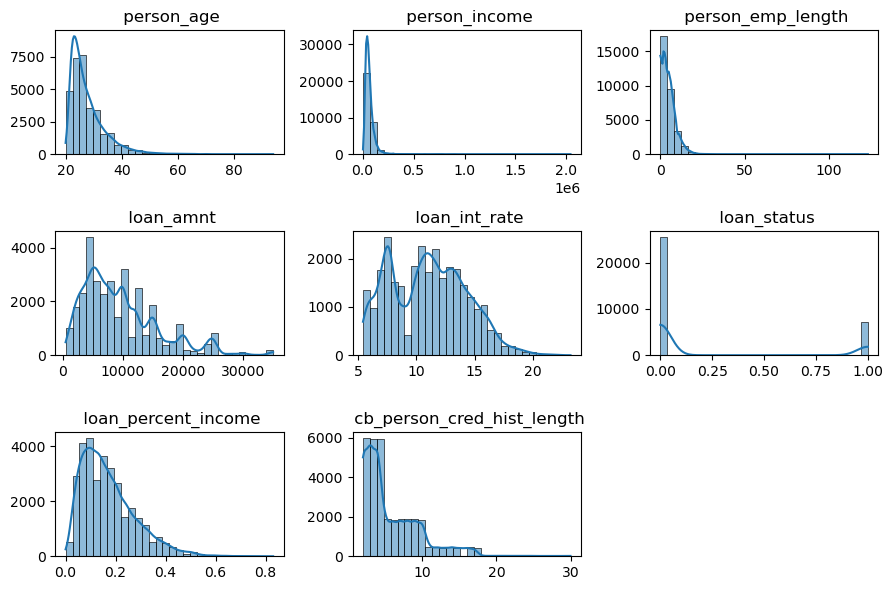

In [24]:
plot_all_histograms(df)

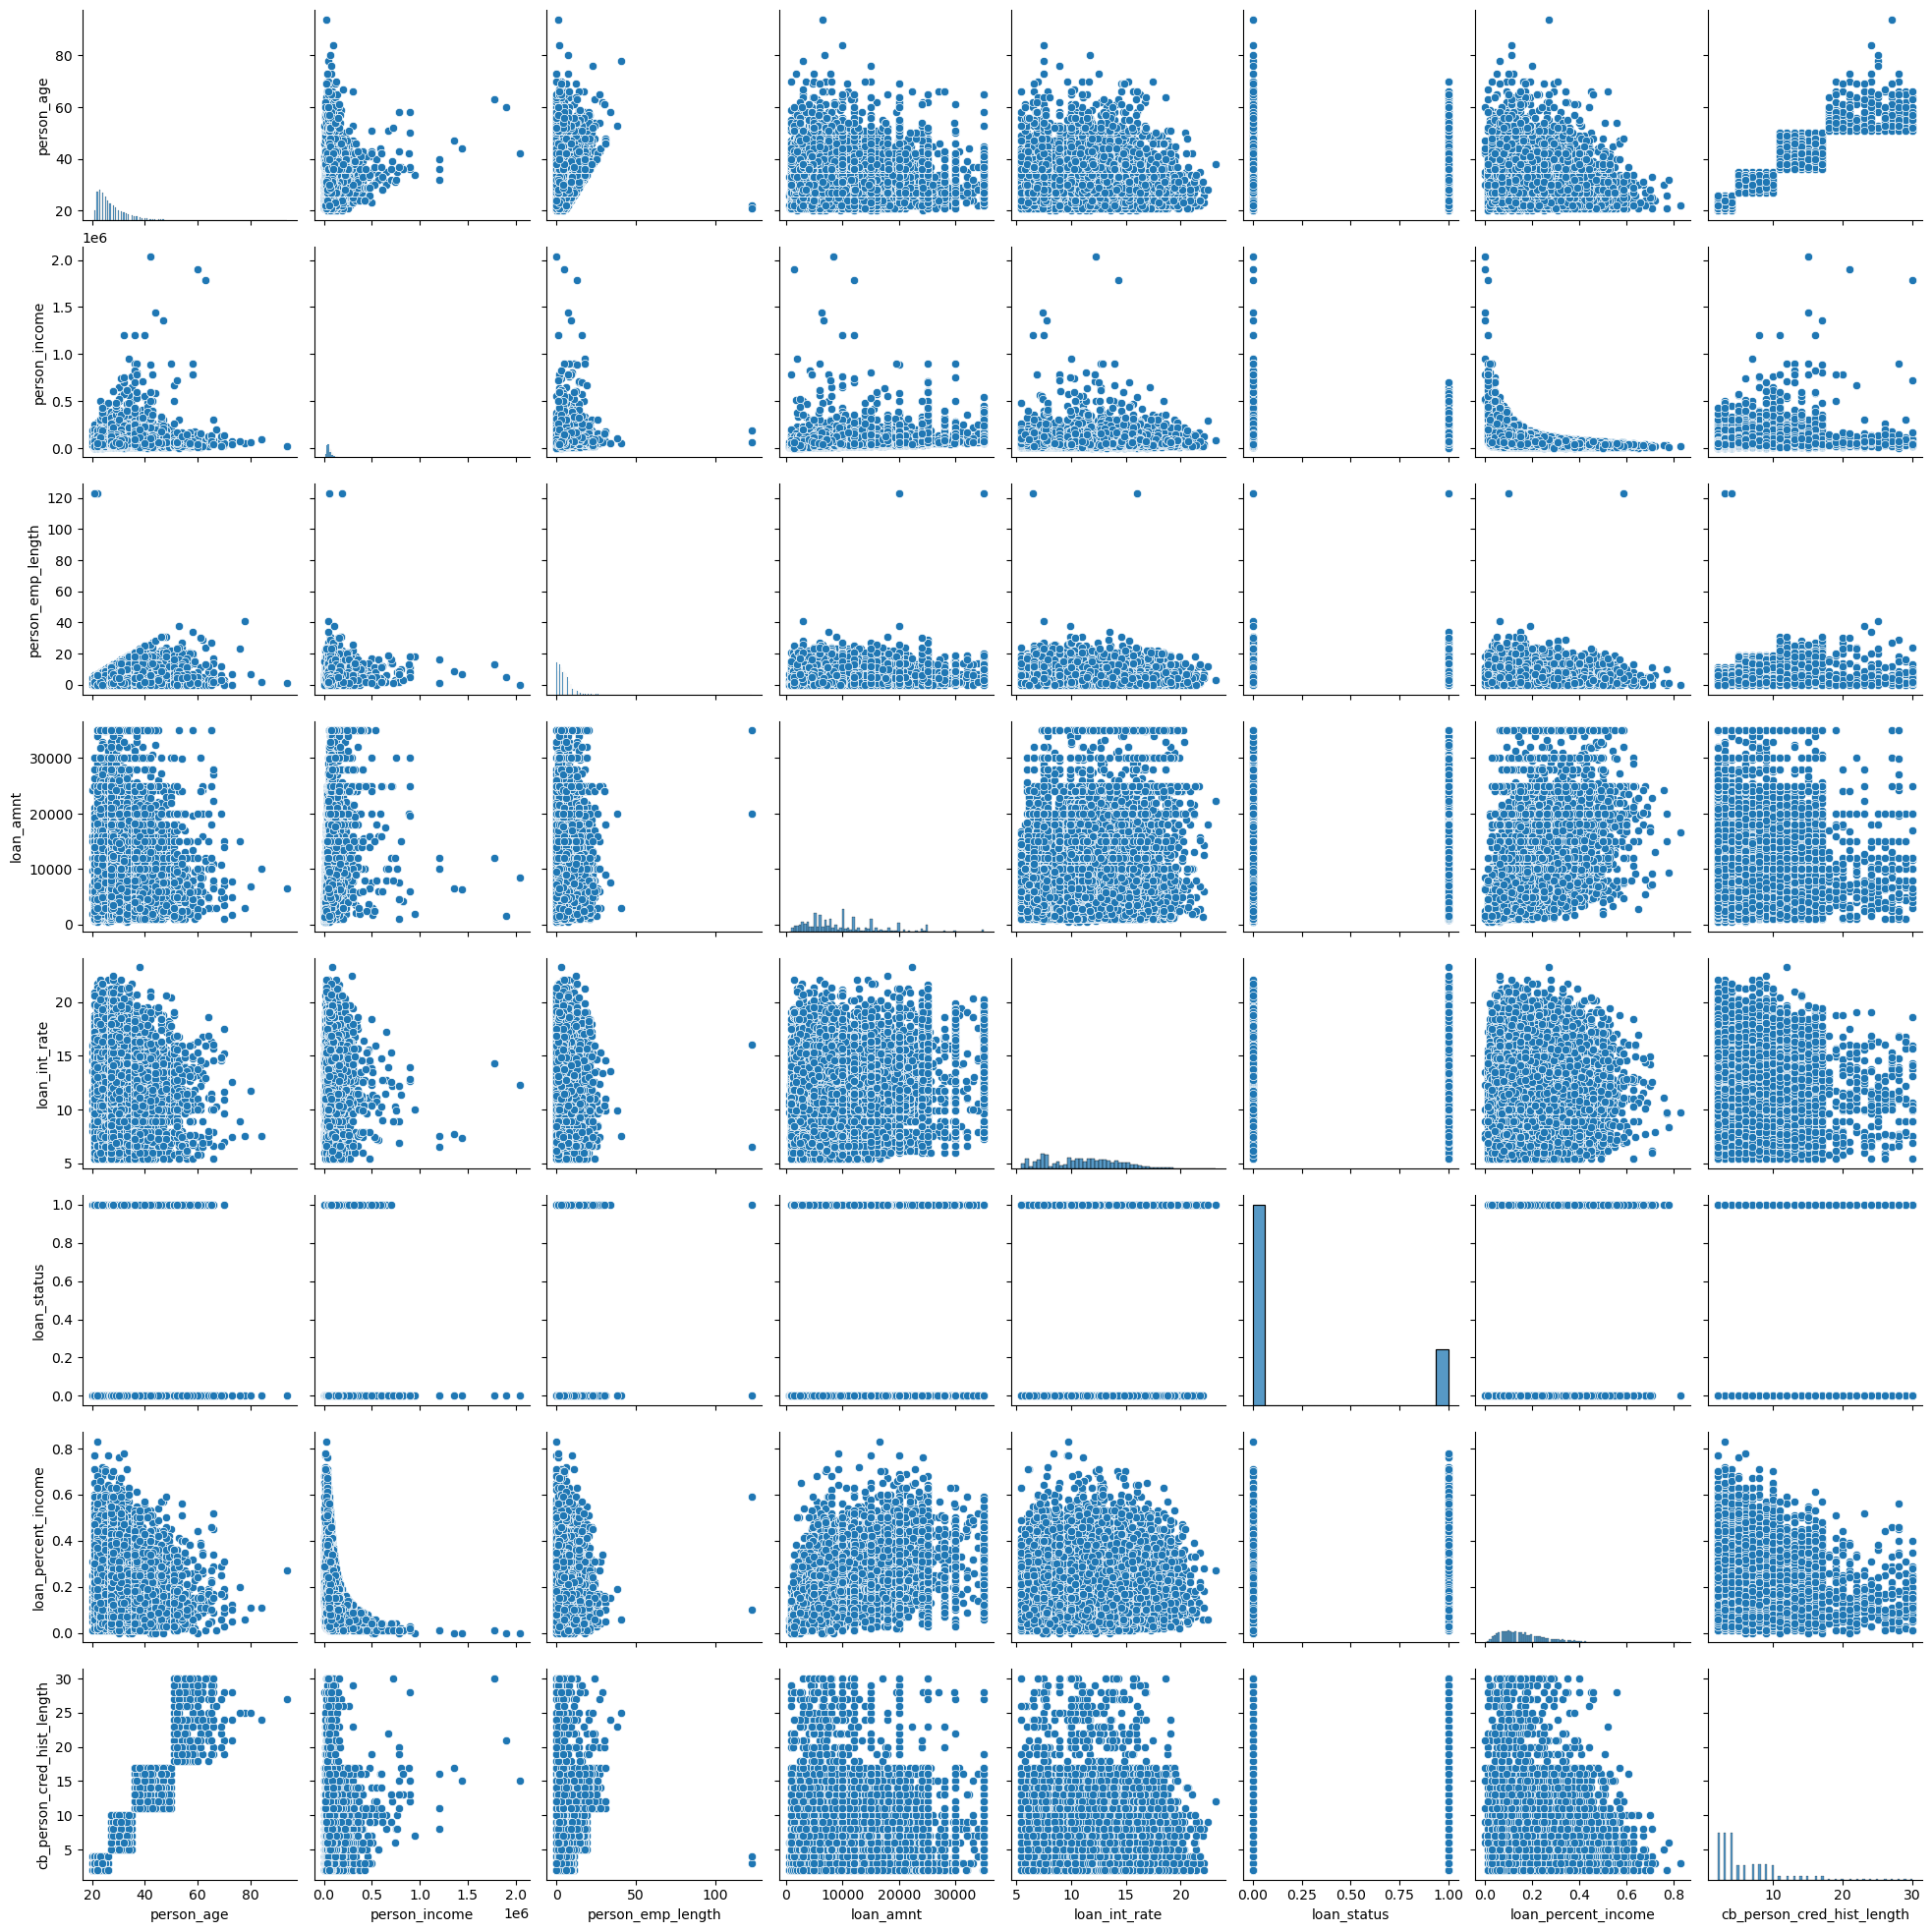

In [25]:
sns.pairplot(data=df)
plt.show()

In [27]:
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [28]:
df["loan_status"].value_counts()

loan_status
0    25468
1     7108
Name: count, dtype: int64

In [44]:
cat_features = [col for col in df.columns if df[col].dtype=='str']

In [45]:
cat_features

['person_home_ownership',
 'loan_intent',
 'loan_grade',
 'cb_person_default_on_file']

In [46]:
num_features = [col for col in df.columns if df[col].dtype!='str']

In [47]:
num_features

['person_age',
 'person_income',
 'person_emp_length',
 'loan_amnt',
 'loan_int_rate',
 'loan_status',
 'loan_percent_income',
 'cb_person_cred_hist_length']

In [48]:
df.shape

(32576, 12)

In [49]:
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [50]:
for feature in cat_features:
    print(df[feature].value_counts())

person_home_ownership
RENT        16443
MORTGAGE    13442
OWN          2584
OTHER         107
Name: count, dtype: int64
loan_intent
EDUCATION            6451
MEDICAL              6071
VENTURE              5717
PERSONAL             5520
DEBTCONSOLIDATION    5212
HOMEIMPROVEMENT      3605
Name: count, dtype: int64
loan_grade
A    10777
B    10448
C     6456
D     3626
E      964
F      241
G       64
Name: count, dtype: int64
cb_person_default_on_file
N    26831
Y     5745
Name: count, dtype: int64


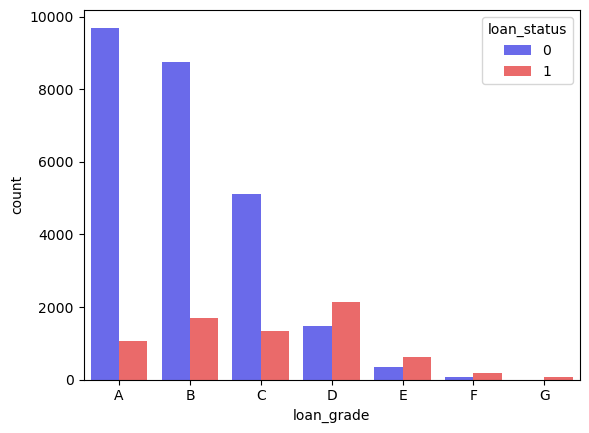

In [78]:
sns.countplot(data=df, x="loan_grade", hue="loan_status",order= ["A", "B", "C", "D", "E", "F", "G"], palette="seismic")
plt.show()

In [87]:
df.groupby(by="loan_grade").agg({
    "loan_status": ["mean", "sum", "count"]
})

loan_status             
                  mean   sum  count
loan_grade                         
A             0.099564  1073  10777
B             0.162806  1701  10448
C             0.207404  1339   6456
D             0.590458  2141   3626
E             0.644191   621    964
F             0.705394   170    241
G             0.984375    63     64

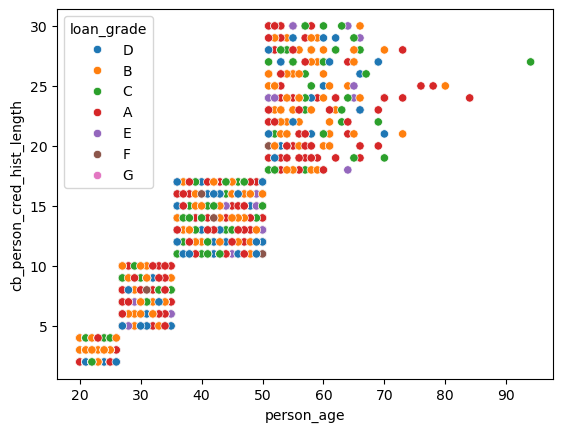

In [91]:
sns.scatterplot(data=df, x="person_age", y="cb_person_cred_hist_length", hue="loan_grade")
plt.show()

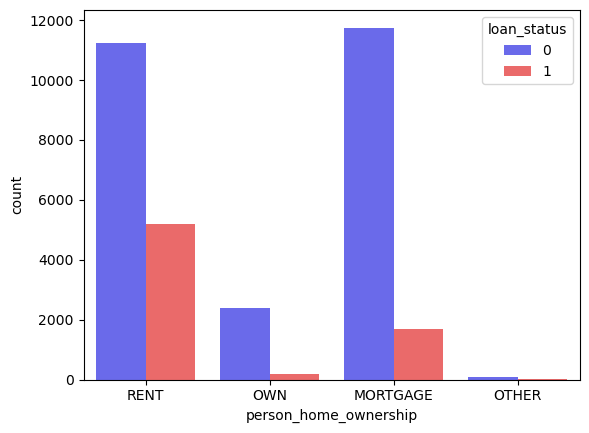

In [92]:
sns.countplot(data=df, x="person_home_ownership", hue="loan_status", palette="seismic")
plt.show()

In [94]:
df.groupby(by="person_home_ownership").agg(
    {
        "loan_status":["count", "sum", "mean"]
    }
)

loan_status                
                            count   sum      mean
person_home_ownership                            
MORTGAGE                    13442  1690  0.125725
OTHER                         107    33  0.308411
OWN                          2584   193  0.074690
RENT                        16443  5192  0.315757

In [95]:
# kirada olanların temerrüde düşme riskinin daha fazla olması makul.<

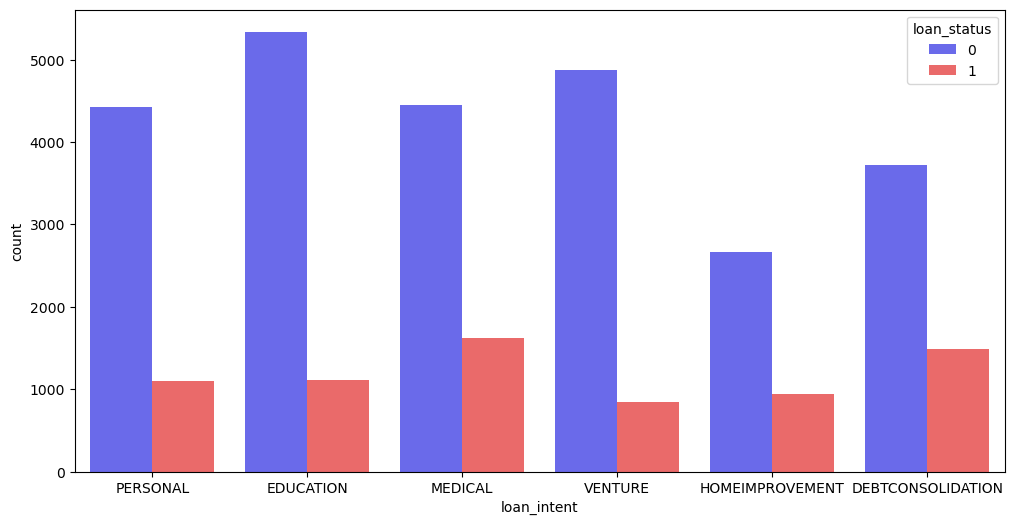

In [102]:
plt.figure(figsize=(12,6))
sns.countplot(data=df, x="loan_intent", hue="loan_status", palette="seismic")

plt.show()

In [103]:
df.groupby(by="loan_intent").agg(
    {
        "loan_status":["count", "sum", "mean"]
    }
)

loan_status                
                        count   sum      mean
loan_intent                                  
DEBTCONSOLIDATION        5212  1490  0.285879
EDUCATION                6451  1111  0.172221
HOMEIMPROVEMENT          3605   941  0.261026
MEDICAL                  6071  1621  0.267007
PERSONAL                 5520  1098  0.198913
VENTURE                  5717   847  0.148155

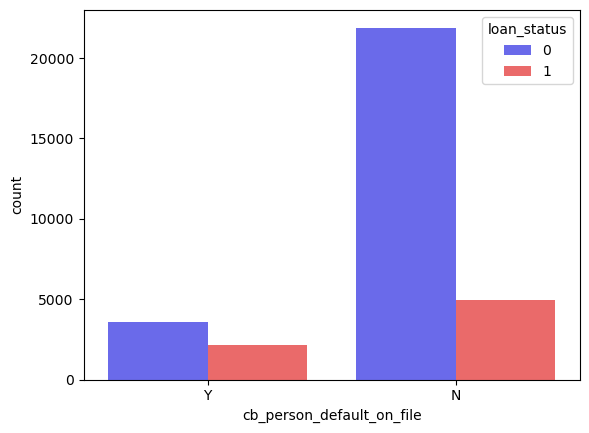

In [106]:
sns.countplot(data=df, x="cb_person_default_on_file", hue="loan_status", palette="seismic")
plt.show()

In [107]:
df.groupby(by="cb_person_default_on_file").agg(
    {
        "loan_status":["count", "sum", "mean"]
    }
)

loan_status                
                                count   sum      mean
cb_person_default_on_file                            
N                               26831  4936  0.183966
Y                                5745  2172  0.378068